*NLP @ HSE DSBA, autumn 2026. Author: Daria Andreeva*

# Seminar 4 — Pretraining and Transfer: BERT and the Shape of a Head

Last week we built a transformer from scratch and trained it on 29 000 German captions. It worked, it beat the LSTM, and it took 15 epochs on a GPU to translate captions — and nothing else. Every task we've touched in this course so far started from zero: zero weights, zero knowledge of English, one dataset.

This week we stop doing that. The body we built last week is the same body, but somebody (Google, 2018) already trained it on 3.3 billion words, and we are going to take those weights and *not* train them, or train them a little, and see how far that gets us. On three tasks, not one.

And here is the thing that I want you to walk out with: the part of the model that is actually *about the task* is tiny. Embarrassingly tiny. We'll count.

### The claim for today:

$$\text{solver} \;=\; \underbrace{\text{pretrained body}}_{\text{shared, 110M}} \;\times\; \underbrace{\text{head}}_{\text{task, a few thousand}} \;\times\; \underbrace{\text{what you unfreeze}}_{\text{a dial}}$$

One pretrained representation, and the task lives in the head — its *output shape*, the *point where it attaches*, and the *axis the softmax runs along*. That last one is the whole difference between NER and question answering, and it's one word in the code.

# Some dependencies

In [12]:
# Colab setup. If needed, uncomment the following lines to install dependencies and clone the repository.
# The notebook reads week 1's results table from ../week01_text_representations, so clone the whole repo.
#!pip install -q "transformers>=5" datasets accelerate evaluate seqeval scikit-learn
#!git clone -q --branch autumn-2026 https://github.com/xufana/dsba_nlp.git
#%cd dsba_nlp/week04_pretraining_transfer

In [13]:
import json
import math
import os
import random
import re
import tempfile
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader

import evaluate                                   # metric scripts from the hub: seqeval for NER, the official SQuAD script
from datasets import Dataset, concatenate_datasets, load_dataset
import transformers
from transformers import (AutoModel, AutoModelForMaskedLM, AutoModelForQuestionAnswering,
                          AutoModelForSequenceClassification, AutoModelForTokenClassification, AutoTokenizer,
                          DataCollatorForTokenClassification, DataCollatorWithPadding, Trainer, TrainerCallback,
                          TrainingArguments)

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()      # no load reports — except once, in 3.4, where the report is the point

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

MODEL_NAME = "bert-base-uncased"                  # the body. Everything today is this one checkpoint.
TOKENIZER_ZOO = ["bert-base-uncased", "gpt2", "albert-base-v2"]   # 1.5: WordPiece, byte-level BPE, Unigram

W1 = "../week01_text_representations"             # week 1's results table is row 0 of ours; its AG News CSV is a check in 0.1
ART_DIR = "artifacts"                             # this week's curves, heads and predictions
RECOMPUTE = False                                 # True: rebuild every artifact with precompute.py (~1 h on an M-series Mac; --full for paper-scale sizes, ~3 h)

# how much runs *live* in class. Small on purpose — the full runs are in artifacts/.
N_LIVE = 2_000                                    # texts / sentences / questions for the live training cells
N_LIVE_TEST = 1_000

device: mps


In [14]:
SEED = 42


def seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def log(msg):
    print(msg, flush=True)


def n_params(module, trainable_only=False):
    return sum(p.numel() for p in module.parameters() if p.requires_grad or not trainable_only)


def show_params(label, module, **parts):
    """One line: `module`'s parameters, split into the named parts. What is left over is "other"."""
    total = n_params(module)
    counts = {name: sum(n_params(m) for m in (part if isinstance(part, (list, tuple)) else [part]))
              for name, part in parts.items()}
    counts["other"] = total - sum(counts.values())
    split = "   ".join(f"{name} {k:,} ({k / total:.1%})" for name, k in counts.items() if k)
    print(f"{label}: {total:,} parameters   |   {split}")


def check(label, ok):
    print(("✓ " if ok else "✗ ") + label)


IGNORE = -100          # the label PyTorch's cross_entropy skips — used for padding, special tokens, word continuations
CLASS_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
NER_TAGS = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC", "B-MISC", "I-MISC"]     # CoNLL-2003, BIO — 3.5

# 0. Where we stopped

## 0.1 The data — AG News, again

AG News is back: same 120 000 news texts, four classes, same test set, same TF-IDF + logistic regression at 0.92 accuracy from week 1. It's here for one reason — the results table. Every row of today's table is one representation of the same texts, and week 1's row 0 is the number to beat.

One change from week 1: the data comes from the Hugging Face hub through `datasets` (it's used mor often for these pipelines), not from a CSV. Everything today — the model, the tokenizer, the data, the training loop, the metrics — is the `transformers` stack, and it's worth seeing how the pieces fit, because this is what you'll write on every project, and it's just kinda nice that somebody wrote everything for you to train your model. A `Dataset` is an Arrow table with `.map`, `.select`, `.shuffle`, and a `ClassLabel` that knows what the integer labels mean; nothing is loaded into memory that isn't asked for.

Two datasets are new, because two of today's tasks are not classification of a whole text — CoNLL-2003 for named entity recognition (5.1) and SQuAD v1.1 for extractive question answering (5.2). Each one is loaded where its task begins.

In [15]:
ds = load_dataset("fancyzhx/ag_news")                             # the same 120 000 / 7 600 split as week 1's CSV
ag_train, ag_test = ds["train"], ds["test"]

In [16]:
print(ag_train)
print("labels:", ag_train.features["label"])
print(ag_train[0])

Dataset({
    features: ['text', 'label'],
    num_rows: 120000
})
labels: ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


## 0.2 The results table

AG News only, one row per way of turning the pretrained body into a classifier. We fill it during the seminar.

In [17]:
results = []


def record(model, trainable, test_acc, seconds=None, note=""):
    results.append({
        "model": model,
        "trainable params": "—" if trainable is None else (f"{trainable / 1e6:.1f}M" if trainable >= 1e6 else f"{trainable:,}"),
        "test acc": round(test_acc, 4),
        "train s": None if seconds is None else round(seconds),
        "note": note,
    })


def show_results():
    return pd.DataFrame(results).set_index("model")


week1 = pd.read_csv(f"{W1}/artifacts/reference_results.csv")
tfidf = week1[week1.representation.str.startswith("tf-idf")].sort_values("accuracy").iloc[-1]
record("TF-IDF + logreg (week 1)", None, tfidf.accuracy, tfidf.fit_s, note=tfidf.representation)
show_results()

,trainable params,test acc,train s,note
model,,,,
TF-IDF + logreg (week 1),—,0.9195,20,"tf-idf, words 1-2"


# 1. Tokenizers: one loop, three criteria

In week 1 we promised to come back to how BPE trains, and in week 2 we did: twenty lines, count the most frequent adjacent pair, glue it, repeat. That's the tokenizer under GPT. It is **not** the tokenizer under BERT, and it is not the one under T5 or ALBERT either. There are three algorithms in use, and the good news is that two of them are the same loop.

Everything in this block runs on a toy: 2 000 AG News texts for educational purposes.

## 1.1 BPE refresh

Same code as in week 2, with two changes. First, the way a word is *split* before training is a parameter, because the two algorithms mark word boundaries differently: BPE appends `</w>` to the last character, WordPiece prefixes `##` to every character that is not the first. Second — and this is the whole point — the *score* of a candidate pair is a parameter too.

In [18]:
def word_frequencies(texts):
    counts = Counter()
    for text in texts:
        counts.update(re.findall(r"[a-z]+|\d+|[^\sa-z\d]", text.lower()))
    return counts


def split_bpe(word):
    return tuple(word) + ("</w>",)                       # "cat" -> ('c', 'a', 't', '</w>')

def split_wordpiece(word):
    return (word[0],) + tuple("##" + c for c in word[1:])   # "cat" -> ('c', '##a', '##t')

def glue(a, b):
    return a + (b[2:] if b.startswith("##") else b)      # '##a' + '##t' -> '##at';  'a' + 't</w>' -> 'at</w>'


def score_bpe(pair_count, unit_count, a, b):
    return pair_count                                    # the most frequent pair

def score_wordpiece(pair_count, unit_count, a, b):
    return pair_count / (unit_count[a] * unit_count[b])  # the pair that is frequent *given how frequent its parts are*


def merge_train(word_freq, num_merges, split, score, min_count=10, verbose=8):
    words = Counter({split(w): f for w, f in word_freq.items()})
    vocab = {u for word in words for u in word}          # the alphabet: every piece we start from
    merges = []
    for i in range(num_merges):
        pairs, units = Counter(), Counter()
        for word, freq in words.items():
            for u in word:
                units[u] += freq
            for a, b in zip(word, word[1:]):
                pairs[(a, b)] += freq
        candidates = [p for p in pairs if pairs[p] >= min_count]   # every real trainer has this cutoff; see 1.2 for why
        if not candidates:
            break
        best = max(candidates, key=lambda p: score(pairs[p], units, *p))

        new_words = Counter()
        for word, freq in words.items():                 # glue the winning pair everywhere it occurs
            out, j = [], 0
            while j < len(word):
                if j < len(word) - 1 and (word[j], word[j + 1]) == best:
                    out.append(glue(*best)); j += 2
                else:
                    out.append(word[j]); j += 1
            new_words[tuple(out)] += freq
        words = new_words
        merges.append(best)
        vocab.add(glue(*best))                           # the vocabulary = the alphabet + one piece per merge
        if i < verbose:
            print(f"merge {i + 1:3d}: {best[0]!r} + {best[1]!r} -> {glue(*best)!r}   (pair seen {pairs[best]:,} times)")
    return merges, vocab


toy_words = word_frequencies(ag_train["text"][:2_000])
print(f"{sum(toy_words.values()):,} word tokens, {len(toy_words):,} distinct\n")

print("BPE")
bpe_merges, bpe_vocab = merge_train(toy_words, num_merges=300, split=split_bpe, score=score_bpe)

101,298 word tokens, 10,408 distinct

BPE
merge   1: 's' + '</w>' -> 's</w>'   (pair seen 13,418 times)
merge   2: 'e' + '</w>' -> 'e</w>'   (pair seen 11,849 times)
merge   3: 'i' + 'n' -> 'in'   (pair seen 8,513 times)
merge   4: 't' + '</w>' -> 't</w>'   (pair seen 7,282 times)
merge   5: 'd' + '</w>' -> 'd</w>'   (pair seen 6,927 times)
merge   6: 't' + 'h' -> 'th'   (pair seen 6,915 times)
merge   7: 'e' + 'r' -> 'er'   (pair seen 6,855 times)
merge   8: 'n' + '</w>' -> 'n</w>'   (pair seen 5,638 times)


The ends of frequent words first — `s</w>` is every plural and every *is*, `e</w>` every *the* — then the frequent bigrams `in`, `th`, `er`. Exactly like on the jokes in week 2: the algorithm has no idea what a word is, it counts.

## 1.2 WordPiece: the same loop, another score

Both trainers do the same thing at every step: over the corpus as it is currently split, pick the adjacent pair $(a, b)$ with the highest score and glue it. Only the score differs:

$$\text{BPE:}\qquad \text{score}(a, b) = \text{freq}(ab)$$

$$\text{WordPiece:}\qquad \text{score}(a, b) = \frac{\text{freq}(ab)}{\text{freq}(a)\;\text{freq}(b)}$$

where $\text{freq}(ab)$ is how many times $a$ and $b$ stand next to each other — `pairs[(a, b)]` in the loop — and $\text{freq}(a)$ how many times $a$ occurs anywhere, next to anything — `units[a]`. `score_bpe` returns the numerator; `score_wordpiece` divides it by the two unit counts. That is the entire difference between the two algorithms at training time.

**Bet:** same corpus, same number of merges, but now the score divides by how frequent the two parts are on their own. Will the first merge still be `s` + `</w>`?

In [19]:
print("WordPiece")
wp_merges, wp_vocab = merge_train(toy_words, num_merges=300, split=split_wordpiece, score=score_wordpiece)

WordPiece
merge   1: '3' + '##9' -> '39'   (pair seen 197 times)
merge   2: '9' + '##2' -> '92'   (pair seen 10 times)
merge   3: '##5' + '##1' -> '##51'   (pair seen 22 times)
merge   4: '1' + '##51' -> '151'   (pair seen 21 times)
merge   5: '7' + '##3' -> '73'   (pair seen 10 times)
merge   6: '##9' + '##8' -> '##98'   (pair seen 11 times)
merge   7: '##9' + '##9' -> '##99'   (pair seen 13 times)
merge   8: '##6' + '##6' -> '##66'   (pair seen 53 times)


It is not. `s</w>` is the most *frequent* pair, but `s` and `</w>` are each so common on their own that seeing them together is not surprising. WordPiece (Schuster & Nakajima 2012; the description everyone cites is in Wu et al. 2016) picks the pair that is frequent *relative to* what you'd expect from its parts — you may recognise pointwise mutual information under a different name. The first merges are digit pairs out of years and prices — pieces whose parts are rare on their own and almost always appear together.

That division has a side effect worth knowing: a pair seen *once*, made of two parts seen once, scores $1/(1 \cdot 1) = 1$, which beats every frequent pair in the corpus. Try it — set `min_count=1` and WordPiece will spend its first merges gluing together the digits of one phone number. Every real trainer has a minimum count for exactly this reason; the loop above uses 10.

Why does Google's justification say "likelihood"? Because $\frac{\text{freq}(ab)}{\text{freq}(a)\,\text{freq}(b)}$ is exactly the factor by which the corpus likelihood under a unigram model goes up when you replace every $a\,b$ with one unit $ab$. BPE maximises compression; WordPiece maximises likelihood. On a real corpus they land close, which is why nobody agonises over the choice — but they are not the same thing, and the first ten merges prove it.

## 1.3 Applying a vocabulary: replaying merges vs longest match

Here is a nuance that most tutorials skip. Training gives you a vocabulary. **Encoding a new word with that vocabulary is a second algorithm**, and BPE and WordPiece disagree on it too:

* BPE *replays the merges* in training order (week 2's `bpe_encode`): the order is the model.
* WordPiece *ignores the merges* and takes the longest piece in the vocabulary that matches the start of the word, then the longest piece that matches the rest, and so on. Greedy longest-match-first. If no piece matches, the whole word is `[UNK]`.

**Bet:** take the WordPiece vocabulary we just trained and encode the test words both ways. On what fraction of words do the two disagree?

In [20]:
def merge_replay(pieces, merges):
    pieces = list(pieces)
    for a, b in merges:                                  # same order as in training — the order *is* the model
        j = 0
        while j < len(pieces) - 1:
            if pieces[j] == a and pieces[j + 1] == b:
                pieces[j:j + 2] = [glue(a, b)]
            else:
                j += 1
    return pieces


def wordpiece_encode(word, vocab, unk="[UNK]"):
    pieces, i = [], 0
    while i < len(word):
        j = len(word)
        while j > i:                                     # the longest piece that starts at i
            piece = word[i:j] if i == 0 else "##" + word[i:j]
            if piece in vocab:
                break
            j -= 1
        if j == i:                                       # nothing matched: give up on the whole word
            return [unk]
        pieces.append(piece)
        i = j
    return pieces


test_words = word_frequencies(ag_test["text"][:2_000])
disagree = [w for w in test_words if merge_replay(split_wordpiece(w), wp_merges) != wordpiece_encode(w, wp_vocab)]
print(f"same vocabulary, two encoders: they disagree on {len(disagree):,} of {len(test_words):,} test words ({len(disagree) / len(test_words):.1%})\n")
for w in disagree[:8]:
    print(f"{w:16s} replay   {merge_replay(split_wordpiece(w), wp_merges)}")
    print(f"{'':16s} longest  {wordpiece_encode(w, wp_vocab)}")

same vocabulary, two encoders: they disagree on 23 of 11,232 test words (0.2%)

1991             replay   ['1', '##99', '##1']
                 longest  ['19', '##9', '##1']
tougher          replay   ['t', '##ough', '##e', '##r']
                 longest  ['to', '##ugh', '##e', '##r']
1994             replay   ['1', '##99', '##4']
                 longest  ['19', '##9', '##4']
tough            replay   ['t', '##ough']
                 longest  ['to', '##ugh']
147              replay   ['1', '##47']
                 longest  ['14', '##7']
1980             replay   ['1', '##98', '##0']
                 longest  ['19', '##8', '##0']
middleweight     replay   ['m', '##i', '##d', '##d', '##l', '##e', '##w', '##e', '##ight']
                 longest  ['m', '##i', '##d', '##d', '##l', '##e', '##w', '##eigh', '##t']
1990             replay   ['1', '##99', '##0']
                 longest  ['19', '##9', '##0']


A vocabulary is not a tokenizer. The same set of pieces, applied by two different rules, gives you two different sequences — and a model trained on one of them has never seen the other. This is the actual reason `tokenizers` saves the merge list *and* the algorithm type in the same json, and the reason you can't swap a model's tokenizer for "an equivalent one".

Longest-match also has a failure mode that replaying merges does not: `[UNK]`. If a word starts with a character the vocabulary has never seen, the whole word is lost. BERT's answer is a 30 000-piece vocabulary that covers every character in its training data — and the famous `[UNK]` for emoji and rare CJK that its training data did not contain.

## 1.4 Unigram: top-down, and Viterbi

The third algorithm (Kudo 2018) does not merge anything. It runs *backwards*:

1. Start with a huge vocabulary — every substring up to some length that occurs in the corpus.
2. Give each piece a probability $p(\text{piece})$, and treat a word as a sequence of independent pieces: $P(\text{segmentation}) = \prod p(\text{piece}_i)$. Estimate the probabilities by EM — an E-step that counts how often each piece is used across *all* segmentations of every word, weighted by their probability, and an M-step that normalises.
3. Throw away the pieces whose removal hurts the corpus likelihood the least. Repeat 2–3 until the vocabulary is the size you want.

Encoding a word is then **Viterbi**: the most probable segmentation, computed by dynamic programming — not a greedy rule, and not a replay.

In [21]:
MAX_PIECE = 6
NEG_INF = float("-inf")


def logsumexp(xs):
    m = max(xs)
    return m if m == NEG_INF else m + math.log(sum(math.exp(x - m) for x in xs))


def unigram_seed(word_freq, seed_size=4_000):
    """Every substring up to MAX_PIECE characters, the `seed_size` most frequent — plus every single
    character, so that any word can always be segmented."""
    counts = Counter()
    for word, freq in word_freq.items():
        for i in range(len(word)):
            for j in range(i + 1, min(len(word), i + MAX_PIECE) + 1):
                counts[word[i:j]] += freq
    seed = {p for p, _ in counts.most_common(seed_size)} | {c for w in word_freq for c in w}
    total = sum(counts[p] for p in seed)
    return {p: math.log(counts[p] / total) for p in seed}


def viterbi(word, logp):
    """The most probable segmentation of `word`: best[i] is the best log-probability of word[:i]."""
    best, back = [0.0] + [NEG_INF] * len(word), [0] * (len(word) + 1)
    for i in range(1, len(word) + 1):
        for j in range(max(0, i - MAX_PIECE), i):
            piece = word[j:i]
            if piece in logp and best[j] + logp[piece] > best[i]:
                best[i], back[i] = best[j] + logp[piece], j
    pieces, i = [], len(word)
    while i > 0:
        pieces.append(word[back[i]:i]); i = back[i]
    return pieces[::-1], best[-1]


def expected_counts(word, freq, logp, counts):
    """E-step for one word: how often each piece is used, summed over *all* segmentations,
    each weighted by its probability. Forward-backward on the segmentation lattice."""
    n = len(word)
    fwd = [0.0] + [NEG_INF] * n                          # log-probability mass of all segmentations of word[:i]
    for i in range(1, n + 1):
        fwd[i] = logsumexp([fwd[j] + logp[word[j:i]] for j in range(max(0, i - MAX_PIECE), i) if word[j:i] in logp] or [NEG_INF])
    bwd = [NEG_INF] * n + [0.0]                          # ... and of word[i:]
    for i in range(n - 1, -1, -1):
        bwd[i] = logsumexp([logp[word[i:j]] + bwd[j] for j in range(i + 1, min(n, i + MAX_PIECE) + 1) if word[i:j] in logp] or [NEG_INF])
    for i in range(n):
        for j in range(i + 1, min(n, i + MAX_PIECE) + 1):
            piece = word[i:j]
            if piece in logp:                            # P(this piece is used at i..j | word)
                counts[piece] += freq * math.exp(fwd[i] + logp[piece] + bwd[j] - fwd[n])


def unigram_train(word_freq, vocab_size, prune=0.2, verbose=True):
    logp = unigram_seed(word_freq)
    while len(logp) > vocab_size:
        counts = Counter()                               # E-step over the corpus
        for word, freq in word_freq.items():
            expected_counts(word, freq, logp, counts)
        total = sum(counts.values())                     # M-step
        logp = {p: math.log(max(counts[p], 1e-9) / total) for p in logp}

        # pruning: how much worse does the corpus get if this piece is gone and its best
        # alternative segmentation has to be used instead?  count x (log p(piece) - log p(alternative))
        loss = {}
        for piece in list(logp):
            if len(piece) == 1:
                continue                                 # single characters are never removed
            lp = logp.pop(piece)
            loss[piece] = counts[piece] * (lp - viterbi(piece, logp)[1])
            logp[piece] = lp
        n_remove = min(len(logp) - vocab_size, max(1, int(prune * len(loss))))
        for piece, _ in sorted(loss.items(), key=lambda x: x[1])[:n_remove]:
            del logp[piece]
        if verbose:
            print(f"vocabulary {len(logp):5d}   corpus log-likelihood {sum(f * viterbi(w, logp)[1] for w, f in word_freq.items()):,.0f}")
    return logp


t = time.time()
uni_logp = unigram_train(toy_words, vocab_size=1_500)
print(f"\n{time.time() - t:.1f}s")

vocabulary  3214   corpus log-likelihood -1,010,607
vocabulary  2583   corpus log-likelihood -992,650
vocabulary  2078   corpus log-likelihood -988,038
vocabulary  1674   corpus log-likelihood -987,849
vocabulary  1500   corpus log-likelihood -987,463

0.9s


Watch the log-likelihood. We remove a fifth of the vocabulary every round and the number barely moves — it even goes *up* at first, because the E/M re-estimation after each round fits the corpus better than the crude seed did, and the pruning only takes pieces the corpus was barely using. That number is the objective; the merges of 1.1 and 1.2 had none, they had a rule.

Now the part that makes Unigram different in kind, not in degree. Because the model is a probability distribution over segmentations, a word does not *have* one tokenization. It has many, each with a probability:

In [22]:
def all_segmentations(word, logp):
    if not word:
        return [([], 0.0)]
    out = []
    for i in range(1, min(len(word), MAX_PIECE) + 1):
        if word[:i] in logp:
            for rest, lp in all_segmentations(word[i:], logp):
                out.append(([word[:i]] + rest, logp[word[:i]] + lp))
    return sorted(out, key=lambda x: -x[1])


for word in ["unbelievable", "microsoft", "tokenization"]:
    segs = all_segmentations(word, uni_logp)
    z = logsumexp([lp for _, lp in segs])
    print(f"{word}: {len(segs)} segmentations.  Viterbi: {viterbi(word, uni_logp)[0]}")
    for pieces, lp in segs[:4]:
        print(f"    P = {math.exp(lp - z):6.1%}   {pieces}")
    print()

unbelievable: 184 segmentations.  Viterbi: ['un', 'bel', 'iev', 'able']
    P =  89.7%   ['un', 'bel', 'iev', 'able']
    P =   3.6%   ['un', 'be', 'l', 'iev', 'able']
    P =   2.2%   ['u', 'n', 'bel', 'iev', 'able']
    P =   2.1%   ['un', 'bel', 'iev', 'a', 'ble']

microsoft: 44 segmentations.  Viterbi: ['micro', 'soft']
    P =  98.0%   ['micro', 'soft']
    P =   2.0%   ['micro', 's', 'of', 't']
    P =   0.0%   ['micro', 's', 'o', 'ft']
    P =   0.0%   ['mic', 'ro', 'soft']

tokenization: 240 segmentations.  Viterbi: ['to', 'ken', 'iz', 'ation']
    P =  85.0%   ['to', 'ken', 'iz', 'ation']
    P =   5.7%   ['to', 'ke', 'n', 'iz', 'ation']
    P =   4.8%   ['to', 'k', 'en', 'iz', 'ation']
    P =   1.5%   ['to', 'ken', 'i', 'z', 'ation']



Read the percentages. The best segmentation holds most of the probability but not all of it — 85%, 90% — and the rest is spread over near-misses that differ by one cut. Kudo's *subword regularization* takes exactly this and, during training, **samples** a segmentation instead of taking the best one — so the model sees `token + ization` on Monday and `tok + en + ization` on Tuesday, and learns that they mean the same thing. It is data augmentation that BPE cannot do, because BPE has no distribution to sample from. (SentencePiece does the E-step as we did, the pruning with a slightly cleverer estimate, and everything in C++; the algorithm is this one.)

❓ **Open question 1:** three algorithms, three different vocabularies of the same size on the same corpus. What would you *measure* to say one is better than another — and better *for what*? (Bostrom & Durrett 2020 have one answer; think of your own before reading theirs.)

## 1.5 Who uses what

| | training | encoding | word boundary | used by |
|---|---|---|---|---|
| **BPE** | merge the most frequent pair | replay the merges | `</w>` / `Ġ` (GPT-2: a space *before* the word, at the byte level) | GPT-1, GPT-2+, RoBERTa, LLaMA |
| **WordPiece** | merge the pair with the best likelihood gain | longest match first | `##` on continuations | BERT, DistilBERT, ELECTRA |
| **Unigram** | prune a large vocabulary by likelihood loss | Viterbi (or sampling) | `▁` on word starts (SentencePiece) | ALBERT, XLNet, T5, mBART |

`##` and `Ġ` and `▁` solve the same problem — "where was the space?" — from opposite ends: one marks *not-the-start*, the other two mark *the start*. All three make detokenization reversible, which is the one property week 1's `word_tokenize` did not have.

In [23]:
zoo = {name: AutoTokenizer.from_pretrained(name) for name in TOKENIZER_ZOO}

for text in ["Unbelievably, the tokenization of 'Sci/Tech' costs 3.5% more in 2004.",
             "Цены на нефть взлетели до рекордного уровня."]:
    print(text)
    for name, tk in zoo.items():
        toks = tk.tokenize(text)
        print(f"  {name:18s} {len(toks):3d} tokens   {toks[:14]}{' ...' if len(toks) > 14 else ''}")
    print()

Unbelievably, the tokenization of 'Sci/Tech' costs 3.5% more in 2004.
  bert-base-uncased   24 tokens   ['un', '##bel', '##ie', '##va', '##bly', ',', 'the', 'token', '##ization', 'of', "'", 'sci', '/', 'tech'] ...
  gpt2                24 tokens   ['Un', 'bel', 'iev', 'ably', ',', 'Ġthe', 'Ġtoken', 'ization', 'Ġof', "Ġ'", 'S', 'ci', '/', 'Tech'] ...
  albert-base-v2      25 tokens   ['▁un', 'be', 'liev', 'ably', ',', '▁the', '▁to', 'ken', 'ization', '▁of', '▁', "'", 's', 'ci'] ...

Цены на нефть взлетели до рекордного уровня.
  bert-base-uncased   37 tokens   ['ц', '##е', '##н', '##ы', 'н', '##а', 'н', '##е', '##ф', '##т', '##ь', 'в', '##з', '##л'] ...
  gpt2                47 tokens   ['Ð', '¦', 'Ðµ', 'Ð½', 'Ñĭ', 'ĠÐ', '½', 'Ð°', 'ĠÐ', '½', 'Ðµ', 'Ñ', 'Ħ', 'ÑĤ'] ...
  albert-base-v2      15 tokens   ['▁', 'цены', '▁', 'на', '▁', 'нефть', '▁', 'взлетели', '▁', 'до', '▁', 'рекордного', '▁', 'уровня'] ...



<!-- CHECK LIVE: the counts below are from bert-base-uncased / gpt2 / albert-base-v2; adjust if the zoo changes. -->

Three things fall out of the output:

* `bert-base-uncased` lowercases and strips accents before it does anything else — that's a *normalizer*, a step before the pre-tokenizer, and it is why an uncased BERT can never tell *Apple* from *apple*. A design decision frozen into the vocabulary, again.
* The Russian sentence under BERT and GPT-2 is a pile of `[UNK]`-adjacent fragments and single bytes: the vocabularies were trained on English. ALBERT's SentencePiece is a little better only because it has more characters. Week 1's "Russian is expensive" result — this is the mechanism.
* GPT-2 has no `[UNK]` at all. Byte-level BPE starts from the 256 bytes, so every string is representable, at the price of a word like *взлетели* costing a token per byte.

# 2. BERT: what the pretraining optimises

BERT (Devlin et al. 2019) is the encoder half of last week's transformer — the stack of self-attention + FFN blocks, no decoder, no cross-attention — trained on 3.3 billion words of Wikipedia and books with a task that needs no labels. `bert-base` is 12 blocks, 12 heads, $d = 768$, and we're going to load it now and mostly leave it alone.

## 2.1 The encoder from week 3, plus three embeddings

Let's count what's in it, block by block, the way we did with our own transformer.

In [24]:
# PyTorch's fused attention kernel on Apple GPUs (MPS) cannot apply dropout, and BERT's attention has 10% of it
# in training — so there every `from_pretrained` below asks for the plain ("eager") implementation; on CUDA the fused one stays.
ATTN = "eager" if torch.backends.mps.is_available() and not torch.cuda.is_available() else None


def set_trainable(model, top_blocks):
    """Freeze the pretrained body inside `model` (whatever `AutoModelFor*` put it in: `model.base_model`),
    then unfreeze its top `top_blocks` encoder blocks. 0 -> only the head trains; "all" -> everything,
    embeddings included. The pooler sits above the last block, so it moves whenever any block does."""
    body = model.base_model
    for p in body.parameters():
        p.requires_grad = top_blocks == "all"
    if top_blocks != "all" and top_blocks > 0:
        for block in body.encoder.layer[len(body.encoder.layer) - top_blocks:]:
            for p in block.parameters():
                p.requires_grad = True
        if getattr(body, "pooler", None) is not None:
            for p in body.pooler.parameters():
                p.requires_grad = True
    return model

In [25]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
body = AutoModel.from_pretrained(MODEL_NAME, add_pooling_layer=True, attn_implementation=ATTN)   # no MLM head; the pooler for 2.4
cfg = body.config
PAD = tokenizer.pad_token_id
D = cfg.hidden_size

print(f"{cfg.num_hidden_layers} blocks x {cfg.num_attention_heads} heads, d = {D}, FFN {cfg.intermediate_size}, "
      f"vocabulary {cfg.vocab_size:,}, max {cfg.max_position_embeddings} positions, activation {cfg.hidden_act}\n")
show_params("bert-base", body,
            token_emb=body.embeddings.word_embeddings,
            position_emb=body.embeddings.position_embeddings,
            segment_emb=body.embeddings.token_type_embeddings,
            encoder=body.encoder,
            pooler=body.pooler)
show_params("  one block", body.encoder.layer[0],
            attention=body.encoder.layer[0].attention, ffn=[body.encoder.layer[0].intermediate, body.encoder.layer[0].output])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 26375.94it/s]

12 blocks x 12 heads, d = 768, FFN 3072, vocabulary 30,522, max 512 positions, activation gelu

bert-base: 109,482,240 parameters   |   token_emb 23,440,896 (21.4%)   position_emb 393,216 (0.4%)   segment_emb 1,536 (0.0%)   encoder 85,054,464 (77.7%)   pooler 590,592 (0.5%)   other 1,536 (0.0%)
  one block: 7,087,872 parameters   |   attention 2,363,904 (33.4%)   ffn 4,723,968 (66.6%)


<!-- CHECK LIVE: 109.5M in total; embeddings 23.8M of it (22%), of which 23.4M is the 30 522 x 768 token table. -->

Read the split. **A fifth of BERT is the embedding table** — 30 522 WordPiece rows of 768 numbers — and every one of the twelve blocks is the same 7.1M we built last week: four $768 \times 768$ matrices in attention, and a $768 \to 3072 \to 768$ FFN that is two thirds of the block. There is nothing in here we haven't written.

What's different from week 3, and matters later:

* **Positions are learned**, not sinusoidal: a $512 \times 768$ table like the token table, one row per position. Which is why BERT has a hard limit of 512 tokens and our transformer didn't — there is no row 513.
* Two special tokens: `[CLS]` in front of everything and `[SEP]` between and after the sentences. `[CLS]` is going to be a whole story.
* A `pooler` — 0.6M parameters, `tanh(W h_{[CLS]} + b)`

The learned position table is a nice thing to look at, cuz nobody told it what a position is:

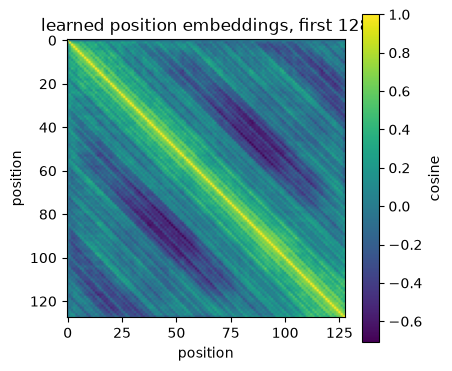

In [26]:
pos = body.embeddings.position_embeddings.weight.detach()
sim = F.normalize(pos, dim=-1) @ F.normalize(pos, dim=-1).T          # cosine similarity between every pair of positions

plt.figure(figsize=(4.6, 4))
plt.imshow(sim[:128, :128].numpy(), cmap="viridis")
plt.colorbar(label="cosine"); plt.xlabel("position"); plt.ylabel("position")
plt.title("learned position embeddings, first 128"); plt.tight_layout(); plt.show()

A bright diagonal band: neighbouring positions got similar vectors, far ones didn't, and nobody wrote that down anywhere. It was learned from the one fact that nearby tokens tend to be related. Compare it with the sinusoidal picture from week 3 — the same structure, arrived at from data instead of from a formula.

## 2.2 Masked language modelling: 15%, then 80/10/10

The pretraining task: hide 15% of the tokens, predict them from the rest. If you look more in details: of the 15% chosen tokens, only **80%** are replaced by `[MASK]`; **10%** are replaced by a *random* token, and **10%** are left *unchanged*, and the model is asked to predict the original at all three kinds of position.

Why? Because at fine-tuning time there is no `[MASK]`. If the model only ever had to *think* at masked positions, it would learn to copy the input everywhere else — and the representation of an unmasked token, which is all we'll use from 3.1 on, would be useless. The 10/10 forces it to *check* every token against its context.

Anyways, we're still using gradients only on 15% of our input, and not learning anything about those who aren't masked or replaced.

In [27]:
@torch.no_grad()
def mask_probabilities(mlm, tokenizer, texts, prompt, device, batch_size=64):
    """For each text, the MLM's distribution over the vocabulary at the [MASK] of `prompt`: [N, V].
    The text goes first, the prompt second, and only the text is ever truncated — so the mask
    is never cut off."""
    mlm.to(device).eval()
    probs = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(texts[i:i + batch_size], [prompt] * len(texts[i:i + batch_size]), truncation="only_first",
                        max_length=128, padding=True, return_tensors="pt").to(device)
        logits = mlm(**enc).logits                                             # [B, L, V]
        at_mask = (enc["input_ids"] == tokenizer.mask_token_id)                # exactly one True per row
        probs.append(logits[at_mask].softmax(-1).cpu())                        # [B, V]
    return torch.cat(probs)


def zero_shot_predict(probs, tokenizer, label_words):
    """Restrict the distribution to the label words and take the most probable one."""
    ids = tokenizer.convert_tokens_to_ids(label_words)
    assert tokenizer.unk_token_id not in ids, "every label word has to be a single token"
    return probs[:, ids].argmax(-1).numpy()

In [28]:
from transformers import AutoModelForMaskedLM

mlm = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).to(device).eval()


@torch.no_grad()
def guesses_at(text, word, k=5):
    """The MLM's top-k tokens at the position of `word` in `text`."""
    enc = tokenizer(text, return_tensors="pt", return_offsets_mapping=True)
    position = next(i for i, (a, b) in enumerate(enc.pop("offset_mapping")[0].tolist()) if a == text.index(word))
    probs = mlm(**enc.to(device)).logits[0, position].softmax(-1)
    top = probs.topk(k)
    return ", ".join(f"{tokenizer.convert_ids_to_tokens(i.item())} {p:.2f}" for p, i in zip(top.values, top.indices))


for text, word in [("She went to the [MASK] to buy some milk.", "[MASK]"),      # 80%: masked
                   ("She went to the banana to buy some milk.", "banana"),      # 10%: a random token
                   ("She went to the store to buy some milk.", "store")]:       # 10%: unchanged
    print(f"{text:48s} -> {guesses_at(text, word)}")

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 19274.50it/s]


She went to the [MASK] to buy some milk.         -> store 0.36, fridge 0.18, kitchen 0.12, refrigerator 0.08, counter 0.04
She went to the banana to buy some milk.         -> banana 0.48, store 0.15, house 0.03, shop 0.02, road 0.01
She went to the store to buy some milk.          -> store 0.99, outlet 0.00, counter 0.00, grocery 0.00, stores 0.00


<!-- CHECK LIVE: with bert-base-uncased the mask gives store/shop/market, the random word gets partly corrected, the real word is mostly copied. -->

Three things fall out of that:

* At `[MASK]` the model does what it was trained for: *store, shop, market, supermarket* — the context is enough.
* At `banana` it doesn't just copy. Part of the mass goes to the input token (it usually is the right answer, in 90% of the training positions), and part goes to *store* / *shop* — the model is checking the token against the sentence and flagging that it doesn't fit. That is the 10% random replacement at work.
* At `store` it copies with high confidence, and the runners-up are still plausible. Every unmasked token's vector carries "what I am" *and* "what would fit here". That second part is what makes the representation useful for everything below.

## 2.3 Zero-shot classification through the mask

Which means we can already classify news without training anything. Add `This news is about [MASK].` after a text as a second segment, read the distribution at the mask, and keep only the four words that name our classes. The model never saw AG News, never saw a label, was never told this is classification. This is *zero-shot*, and it is the direct ancestor of "prompting".

**Bet:** accuracy? Week 1's TF-IDF is 0.92; random is 0.25.

In [29]:
PROMPT = "This news is about [MASK]."
live_test = ag_test.select(range(N_LIVE_TEST))

t = time.time()
probs = mask_probabilities(mlm, tokenizer, live_test["text"], PROMPT, device)
print(f"{len(live_test):,} texts through the MLM in {time.time() - t:.0f}s on {device}")

label_words = ["world", "sports", "business", "technology"]
pred = zero_shot_predict(probs, tokenizer, label_words)
gold = np.array(live_test["label"])
print(f"\nzero-shot accuracy: {(pred == gold).mean():.3f}")
for c in range(4):
    goes_to = ", ".join(f"{CLASS_NAMES[k]} {n}" for k, n in Counter(pred[gold == c]).most_common(2))
    print(f"  {CLASS_NAMES[c]:9s} {(pred[gold == c] == c).mean():.3f}   (predicted as: {goes_to})")

1,000 texts through the MLM in 8s on mps

zero-shot accuracy: 0.260
  World     0.000   (predicted as: Business 260, Sports 5)
  Sports    0.084   (predicted as: Business 251, Sports 23)
  Business  0.995   (predicted as: Business 204, Sci/Tech 1)
  Sci/Tech  0.130   (predicted as: Business 220, Sci/Tech 33)


<!-- CHECK LIVE: v1 lands around 0.55–0.65 overall, with World far below the others. -->

Hm. Not random, but not good either — and the per-class numbers say it's not *evenly* not good. Sports is fine; World is a disaster. Before blaming the model: what does it actually *want* to put in the mask for World news? Let's ask it.

In [30]:
world = probs[torch.tensor(gold == 0)]
top_words = Counter()
for row in world:
    top_words.update(tokenizer.convert_ids_to_tokens(row.topk(10).indices.tolist()))
print(top_words.most_common(20))

[('us', 218), ('me', 191), ('you', 176), ('him', 170), ('iran', 153), ('china', 148), ('america', 144), ('india', 92), ('politics', 67), ('israel', 58), ('love', 56), ('terrorism', 56), ('iraq', 54), ('her', 53), ('afghanistan', 53), ('money', 49), ('russia', 48), ('australia', 35), ('islam', 35), ('africa', 34)]


It says *politics*. And *war*, and *iraq* — 2004, remember. "World" is the name a newsroom gave the section; the texts in it are about politics, and the model knows the texts, not the section. Rename the class, keep everything else:

In [31]:
label_words = ["politics", "sports", "business", "technology"]
pred = zero_shot_predict(probs, tokenizer, label_words)
print(f"zero-shot accuracy with 'politics': {(pred == gold).mean():.3f}")
for c in range(4):
    print(f"  {CLASS_NAMES[c]:9s} {(pred[gold == c] == c).mean():.3f}")

zs = json.load(open(f"{ART_DIR}/zero_shot.json"))              # the same thing on the full test set
for name, run in zs["label_sets"].items():
    print(f"\nfull test set, {run['words']}: {run['accuracy']}   per class {run['per_class']}")
record("zero-shot MLM, " + "/".join(zs["label_sets"]["v2"]["words"]), 0, zs["label_sets"]["v2"]["accuracy"], note=f"prompt: {zs['prompt']}")

zero-shot accuracy with 'politics': 0.449
  World     0.765
  Sports    0.080
  Business  0.932
  Sci/Tech  0.123

full test set, ['world', 'sports', 'business', 'technology']: 0.3011   per class {'World': 0.0011, 'Sports': 0.0753, 'Business': 0.9921, 'Sci/Tech': 0.1358}

full test set, ['politics', 'sports', 'business', 'technology']: 0.4682   per class {'World': 0.7495, 'Sports': 0.0668, 'Business': 0.93, 'Sci/Tech': 0.1263}


<!-- REVISE AFTER PRECOMPUTE: the v2 number. -->

Now that's a different story — one word in the prompt, ten to fifteen points of accuracy. Two lessons, both of which will come back in the LLM weeks:

1. A pretrained model has *capabilities* it was never trained for, reachable through the pretraining interface. That's the whole thesis of prompting, three years early.
2. The prompt is a hyperparameter, and a fragile one. We got lucky that a single word fixed it; usually you find out by trying.

And zero-shot is still ten points under TF-IDF. The model knows more than a bag of words — we can see that in the mask — but it has no way to *use* what it knows for our four classes. Time to attach something.



## 2.4 NSP, the pooler, and the `[CLS]` myth

BERT's second pretraining task, **next-sentence prediction**: show two sentences, `[CLS] A [SEP] B [SEP]`, and predict whether B followed A in the original text. The prediction is made from the `[CLS]` position — through the pooler, `tanh(W h_{[CLS]} + b)`, and one Linear on top. This is the *only* reason `[CLS]` has any meaning at all: it's a position with no token of its own, so whatever ends up in it is whatever the pretraining task pushed there.

Which brings us to a sentence that appears in roughly every BERT tutorial, including last year's version of this seminar: *"`[CLS]` contains a representation of the whole text, so we can use it as a sentence embedding."* Let's test that, cuz it's cheap. Three ways to turn the body's output into one vector per text, a logistic regression on top of each, no fine-tuning:

* the **pooler** output — what NSP actually trained;
* the raw **`[CLS]`** vector from the last layer;
* the **mean** of all token vectors from the last layer.

**Bet:** rank the three.

In [32]:
def encode_agnews(tokenizer, ds, max_len=128):
    """text -> input_ids / attention_mask, unpadded: the collator pads every batch to its own longest text."""
    return ds.map(lambda batch: tokenizer(batch["text"], truncation=True, max_length=max_len), batched=True, remove_columns=["text"])


def accuracy_metric(p):
    return {"accuracy": round(float((p.predictions.argmax(-1) == p.label_ids).mean()), 4)}


@torch.no_grad()
def extract_features(body, ds, collator, device, batch_size=64):
    """Three summaries of every text from the frozen body: the pooler output, the raw [CLS]
    vector, and the mean of all token vectors — from the last layer. Plus the mean-pool from
    every layer (embeddings = layer 0), for the probe by depth."""
    body.to(device).eval()
    loader = DataLoader(ds.remove_columns("label"), batch_size=batch_size, collate_fn=collator)
    pooler, cls, mean, by_layer = [], [], [], []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = body(**batch, output_hidden_states=True)
        m = batch["attention_mask"].unsqueeze(-1).float()                          # [B, L, 1]
        means = torch.stack([(h * m).sum(1) / m.sum(1) for h in out.hidden_states])  # [n_layers+1, B, d]
        by_layer.append(means.cpu())
        mean.append(means[-1].cpu())
        cls.append(out.last_hidden_state[:, 0].cpu())
        if out.pooler_output is not None:
            pooler.append(out.pooler_output.cpu())
    return {"pooler": torch.cat(pooler) if pooler else None, "cls": torch.cat(cls), "mean": torch.cat(mean),
            "by_layer": torch.cat(by_layer, dim=1)}


def logreg_accuracy(X_train, y_train, X_test, y_test):
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler().fit(X_train)
    clf = LogisticRegression(max_iter=2000).fit(scaler.transform(X_train), y_train)
    return round(float(clf.score(scaler.transform(X_test), y_test)), 4)

In [33]:
live_train = ag_train.shuffle(seed=SEED).select(range(N_LIVE))
collator = DataCollatorWithPadding(tokenizer)                     # pads each batch to its longest text — week 2's pad_batch, from the library
live_tr, live_te = encode_agnews(tokenizer, live_train), encode_agnews(tokenizer, live_test)
y_train, y_test = np.array(live_train["label"]), np.array(live_test["label"])
print(live_tr, "\n")

t = time.time()
f_train = extract_features(body, live_tr, collator, device)
f_test = extract_features(body, live_te, collator, device)
print(f"{len(live_train) + len(live_test):,} texts through the body in {time.time() - t:.0f}s\n")

for name in ["pooler", "cls", "mean"]:
    acc = logreg_accuracy(f_train[name].numpy(), y_train, f_test[name].numpy(), y_test)
    print(f"{name:7s} + logreg on {len(live_train):,} texts: {acc}")

probe = json.load(open(f"{ART_DIR}/features_probe.json"))       # the same on more training texts and the full test set
print(f"\non {probe['n_train']:,} training texts: {probe['summary']}")
for name, label in [("pooler", "pooler + logreg"), ("cls", "frozen [CLS] + logreg"), ("mean", "frozen mean-pool + logreg")]:
    record(label, 0, probe["summary"][name], note=f"body frozen, {probe['n_train']:,} texts")
show_results()

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
}) 

3,000 texts through the body in 23s

pooler  + logreg on 2,000 texts: 0.822
cls     + logreg on 2,000 texts: 0.825
mean    + logreg on 2,000 texts: 0.857

on 10,000 training texts: {'pooler': 0.8679, 'cls': 0.8579, 'mean': 0.8659}


,trainable params,test acc,train s,note
model,,,,
TF-IDF + logreg (week 1),—,0.9195,20.0,"tf-idf, words 1-2"
"zero-shot MLM, politics/sports/business/technology",0,0.4682,NaN,prompt: This news is about [MASK].
pooler + logreg,0,0.8679,NaN,"body frozen, 10,000 texts"
frozen [CLS] + logreg,0,0.8579,NaN,"body frozen, 10,000 texts"
frozen mean-pool + logreg,0,0.8659,NaN,"body frozen, 10,000 texts"


<!-- Revised 2026-09-23 against artifacts/features_probe.json (10 000 train, 7 600 test): pooler 0.868, [CLS] 0.858, mean 0.866. -->

Read the table rather than skimming it:

* **You can't rank them.** Pooler 0.868, mean 0.866, `[CLS]` 0.858 — one point apart, on a test set where the standard error of an accuracy is about 0.004. 
* **All three lose to TF-IDF from week 1, by five points.** A 110M-parameter model, pretrained on 3.3B words, frozen and probed, does not beat counting words with the right weights. Frozen features from a model that was never asked to separate topics are not topic features. (This is the result that made Reimers & Gurevych build Sentence-BERT in 2019: raw BERT vectors are *not* sentence embeddings until you train them to be.)
* RoBERTa (Liu et al. 2019) dropped NSP entirely, trained on more data, and got better on every benchmark. The pooler is a 0.6M-parameter fossil that, on this table, neither costs nor gains anything. It is still in every `bert-base` checkpoint, and `AutoModelForSequenceClassification` still reads it — hold that thought for 3.3.

So: the body knows things, the mask proves it, the frozen vectors don't hand them over, and the number to beat is still 0.92. What we haven't done yet is *train anything on the task*. The smallest possible thing we could train is one Linear — a head.

# 3. The head: shape, attachment point, loss

## 3.1 One formula, one table

Whatever the task, the body does one thing: a batch of $B$ texts, each $L$ tokens long, goes in, and a tensor

$$H = \text{body}(x) \in \mathbb{R}^{B \times L \times d}$$

comes out — one $d = 768$ vector per token. A **head** is whatever turns $H$ into the answer, and for every task we'll meet it is *one Linear layer*. The tasks differ in three places only: **which part of $H$** the Linear reads, **what shape** comes out, and **along which axis the softmax runs** inside the loss.

| task | reads from $H$ | logits | softmax over | loss | ignored |
|---|---|---|---|---|---|
| **sequence classification** (AG News) | one vector: `H[:, 0]`, the `[CLS]` position — `[B, d]` | `[B, C]` | $C$ classes | cross-entropy, once per text | padding (never reaches the head) |
| **token classification** (NER) | every vector: `[B, L, d]` | `[B, L, C]` | $C$ classes, *at each position* | cross-entropy, once per token | `-100`: `[CLS]`, `[SEP]`, padding, word continuations |
| **span extraction** (QA) | every vector: `[B, L, d]` | `[B, L, 2]` → two `[B, L]` | $L$ **positions** | cross-entropy twice, "classes" = positions | question tokens, padding — via the answer post-processing |

Look at rows 2 and 3. NER and QA both read *all* of $H$ and both produce a `[B, L, something]` tensor. The difference is one word: NER normalises **over classes** at every position ("what is this token"), QA normalises **over positions** ("which token starts the answer"). The tensor is the same shape. The axis is the task.

That is also why extractive QA is *not* "tag every token as start / end / neither" — the version you'd write if you thought of it as NER with three labels. Tagging gives you a decision per token, independently, so you can get four starts and no end. Two softmaxes over positions give you exactly one start and exactly one end, by construction. Same Linear, same $H$, different axis, different task.

## 3.2 The heads, by hand

Here they are. Read the shapes in the comments, they're the whole story.

In [34]:
class SequenceHead(nn.Module):
    """[B, L, d] -> [B, C].  One vector per text — the [CLS] position — then one Linear.
    Softmax (inside the loss) runs over C: "which class is this text"."""

    def __init__(self, d, n_classes, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        self.linear = nn.Linear(d, n_classes)

    def forward(self, H, attention_mask=None):
        return self.linear(self.drop(H[:, 0]))                  # [B, d] -> [B, C]


class TokenHead(nn.Module):
    """[B, L, d] -> [B, L, C].  The same Linear at every position.
    Softmax runs over C, separately at each position: "which tag is this token"."""

    def __init__(self, d, n_classes, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        self.linear = nn.Linear(d, n_classes)

    def forward(self, H, attention_mask=None):
        return self.linear(self.drop(H))                        # [B, L, d] -> [B, L, C]


class SpanHead(nn.Module):
    """[B, L, d] -> two [B, L].  A Linear with two outputs at every position: a start score and
    an end score. Softmax runs over L — over positions — "which token starts the answer"."""

    def __init__(self, d, dropout=0.0):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        self.linear = nn.Linear(d, 2)

    def forward(self, H, attention_mask=None):
        start, end = self.linear(self.drop(H)).unbind(-1)       # [B, L, 2] -> [B, L], [B, L]
        return start, end


def sequence_loss(logits, labels):
    return F.cross_entropy(logits, labels)                                   # normalises over the last axis: C

def token_loss(logits, labels):
    return F.cross_entropy(logits.flatten(0, 1), labels.flatten(), ignore_index=IGNORE)   # over C, at every kept position

def span_loss(scores, labels):
    start, end = scores                                                      # each [B, L]
    return (F.cross_entropy(start, labels[:, 0]) + F.cross_entropy(end, labels[:, 1])) / 2   # over L: the "classes" are positions

In [35]:
heads = {"sequence (4 classes)": SequenceHead(D, 4), "token (9 tags)": TokenHead(D, len(NER_TAGS)), "span": SpanHead(D)}
for name, head in heads.items():
    print(f"{name:22s} {n_params(head):6,} parameters   = {n_params(head) / n_params(body):.4%} of the body")

sequence (4 classes)    3,076 parameters   = 0.0028% of the body
token (9 tags)          6,921 parameters   = 0.0063% of the body
span                    1,538 parameters   = 0.0014% of the body


Six thousand parameters for NER against a hundred and ten million in the body. If the body's vectors already contain "this token is the name of a person", a Linear is enough to read it out — and if they don't, no head will fix it. Everything from here on is about how much of that hundred million has to move.

One argument to keep an eye on: `token_type_ids`, the segment embedding from 2.1. For AG News and NER it's all zeros and it doesn't matter; for QA it is what tells the model where the question ends and the paragraph starts. It's an easy argument to drop when you write the body-plus-head wrapper yourself and the model trains anyway, a bit worse, and nobody notices. The library's classes below pass it, and the collator pads it. That is one argument for using them.



## 3.3 What `transformers` does — the same five lines

`AutoModelForSequenceClassification`, `AutoModelForTokenClassification`, `AutoModelForQuestionAnswering`: the library ships one class per head. There is no magic in them, and it's worth reading the source once, so let's do that:

In [36]:
import inspect
from transformers.models.bert import modeling_bert as mb

for cls in [mb.BertForSequenceClassification, mb.BertForTokenClassification, mb.BertForQuestionAnswering]:
    print(f"===== {cls.__name__}")
    init = inspect.getsource(cls.__init__)
    print("\n".join(l for l in init.split("\n") if re.search(r"self\.(bert|dropout|classifier|qa_outputs) =", l)))
    print("    ...")
    forward = inspect.getsource(cls.forward)
    print("\n".join(l for l in forward.split("\n") if re.search(r"outputs\[|logits = |logits\.split|_logits = ", l)))
    print()

===== BertForSequenceClassification
        self.bert = BertModel(config)
        self.dropout = nn.Dropout(classifier_dropout)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
    ...
        pooled_output = outputs[1]
        logits = self.classifier(pooled_output)

===== BertForTokenClassification
        self.bert = BertModel(config, add_pooling_layer=False)
        self.dropout = nn.Dropout(classifier_dropout)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
    ...
        sequence_output = outputs[0]
        logits = self.classifier(sequence_output)

===== BertForQuestionAnswering
        self.bert = BertModel(config, add_pooling_layer=False)
        self.qa_outputs = nn.Linear(config.hidden_size, config.num_labels)
    ...
        sequence_output = outputs[0]
        logits = self.qa_outputs(sequence_output)
        start_logits, end_logits = logits.split(1, dim=-1)
        start_logits = start_logits.squeeze(-1).contiguous()


Three things to notice, all of them things we just wrote:

* **Sequence classification reads `outputs[1]`** — the pooler. Our `SequenceHead` reads `H[:, 0]` directly.
* **QA is `Linear(d, 2)` then `split` into two `[B, L]` tensors.** Exactly `SpanHead`. And the loss in the source — go look — is two `CrossEntropyLoss` calls over the position axis.

One more thing these classes do that ours don't, and it matters: when you load one, the body weights come from the checkpoint and **the head weights are random**. The library prints a load report about it — `classifier.weight  MISSING`. What a random head does:



## 3.4 An untrained head

In [37]:
TRAINER_DIR = os.path.join(tempfile.gettempdir(), "week04_trainer")     # Trainer wants a directory even when it saves nothing


class EpochTimer(TrainerCallback):
    """Seconds since the start of training at the end of every epoch — the "bill" column of the tables."""

    def on_train_begin(self, args, state, control, **kw):
        self.t0, self.seconds = time.time(), []

    def on_epoch_end(self, args, state, control, **kw):
        self.seconds.append(round(time.time() - self.t0, 1))


def train(model, train_ds, eval_ds, collator, compute_metrics=None, epochs=2, lr=2e-5, batch_size=32, seed=SEED, quiet=False):
    """One Trainer for every task. AdamW on the trainable parameters only, the learning rate warmed up
    linearly over the first 10% of the steps and decayed linearly to zero after — BERT's fine-tuning
    recipe, spelled out as TrainingArguments. `compute_metrics` runs on the eval set after every epoch.
    Returns the trainer (for predictions) and the curves: train loss, seconds and every eval metric, by epoch."""
    args = TrainingArguments(output_dir=TRAINER_DIR, per_device_train_batch_size=batch_size, per_device_eval_batch_size=64,
                             num_train_epochs=epochs, learning_rate=lr, weight_decay=0.01, warmup_steps=0.1,   # < 1: a fraction of the steps
                             lr_scheduler_type="linear", eval_strategy="epoch", logging_strategy="epoch", save_strategy="no",
                             report_to=[], seed=seed, disable_tqdm=quiet)
    timer = EpochTimer()
    trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=eval_ds, data_collator=collator,
                      compute_metrics=compute_metrics, callbacks=[timer])
    trainer.train()
    curves = {"epoch": [], "train_loss": [], "seconds": timer.seconds, "trainable_params": n_params(model, trainable_only=True)}
    for entry in trainer.state.log_history:                     # one training entry and one eval entry per epoch
        if "loss" in entry:
            curves["epoch"].append(int(round(entry["epoch"])))
            curves["train_loss"].append(round(entry["loss"], 4))
        for k, v in entry.items():
            if k.startswith("eval_") and not k.endswith(("_runtime", "_per_second")):
                curves.setdefault(k if k == "eval_loss" else k[len("eval_"):], []).append(v)
    return trainer, curves


def predict(model, ds, collator, compute_metrics=None):
    """Run `model` over `ds` with no training at all: a Trainer built only for `.predict`."""
    args = TrainingArguments(output_dir=TRAINER_DIR, per_device_eval_batch_size=64, report_to=[], disable_tqdm=True)
    return Trainer(model=model, args=args, data_collator=collator, compute_metrics=compute_metrics).predict(ds)

In [38]:
! uv add 'transformers[torch]'

Resolved 183 packages in 29ms
Audited 142 packages in 2ms


In [39]:
seed_all()
transformers.logging.set_verbosity_warning()                     # once: the load report is the point here
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=4, attn_implementation=ATTN)
transformers.logging.set_verbosity_error()
set_trainable(model, top_blocks=0)                                # body frozen, pooler included — only `classifier` will move

show_params("sequence classifier", model, body=model.bert, head=model.classifier)
acc = predict(model, live_te, collator, accuracy_metric).metrics["test_accuracy"]
print(f"untrained head: test accuracy {acc}   (random = 0.25)")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4460.59it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

sequence classifier: 109,485,316 parameters   |   body 109,482,240 (100.0%)   head 3,076 (0.0%)
untrained head: test accuracy 0.255   (random = 0.25)


Random, as it should be: the body is fine, the Linear on top of it has never seen a label. The "pretrained model" you download for a task is *this* — a pretrained body and a coin-flip head — until you train the head.

So let's train it. The body stays frozen — the pooler with it, it's inside `model.bert` — and the only thing that moves is the 3 076 parameters of the head. One epoch on `N_LIVE` texts, learning rate $10^{-3}$ — high, because a lone Linear can take it (compare the $2 \cdot 10^{-5}$ we'll need once the body moves).

The loop is `Trainer`'s. `train` above spells out the arguments once — AdamW with weight decay, a linear warm-up over the first 10% of the steps and a linear decay to zero, batches padded by the collator, `compute_metrics` on the eval set after every epoch, a callback that keeps the clock — and every task today reuses it with a different model, collator and metric:

In [46]:
seed_all()
trainer, curves = train(model, live_tr, live_te, collator, accuracy_metric, epochs=1, lr=1e-3, batch_size=32)
record(f"head only, live ({N_LIVE:,} texts, 1 epoch)", curves["trainable_params"], curves["accuracy"][-1], curves["seconds"][-1],
       note="body frozen, pooler included")
show_results()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.206232,1.163149,0.566000


,trainable params,test acc,train s,note
model,,,,
TF-IDF + logreg (week 1),—,0.9195,20.0,"tf-idf, words 1-2"
"zero-shot MLM, politics/sports/business/technology",0,0.4682,NaN,prompt: This news is about [MASK].
pooler + logreg,0,0.8679,NaN,"body frozen, 10,000 texts"
frozen [CLS] + logreg,0,0.8579,NaN,"body frozen, 10,000 texts"
frozen mean-pool + logreg,0,0.8659,NaN,"body frozen, 10,000 texts"
"head only, live (2,000 texts, 1 epoch)","3,076",0.4910,14.0,"body frozen, pooler included"
"head only, live (2,000 texts, 1 epoch)","3,076",0.5660,17.0,"body frozen, pooler included"


<!-- CHECK LIVE: about the pooler + logreg row of 2.4, on 2 000 texts. -->

Not far off the frozen-features-plus-logreg rows from 2.4 — the *pooler* row, to be exact, and it *is* that row: the library's head reads the pooler output (3.3), the pooler is frozen with the body, and a Linear on a frozen vector trained with SGD is a logistic regression on that vector. Same thing, written in `torch`. That's the bottom setting of the dial. Now let's turn it.


# 4. Transfer is a dial

So far the dial has one position: the body frozen (2.4, 3.4). The other end — everything trained — and everything in between is a choice, and it's a choice you'll make on every project — usually with a GPU budget in mind. Let's turn the dial slowly, on AG News, where we have the whole table.

## 4.1 A linear probe per layer

First a question about the frozen body that we skipped in 2.4: we took the *last* layer's vectors. BERT has thirteen (the embeddings, then twelve blocks), and `extract_features` kept the mean-pool of every one of them. A logistic regression on each — a **linear probe** — asks: *which layer knows the topic best?*

**Bet:** the last one? The middle? Draw the curve before running the cell.

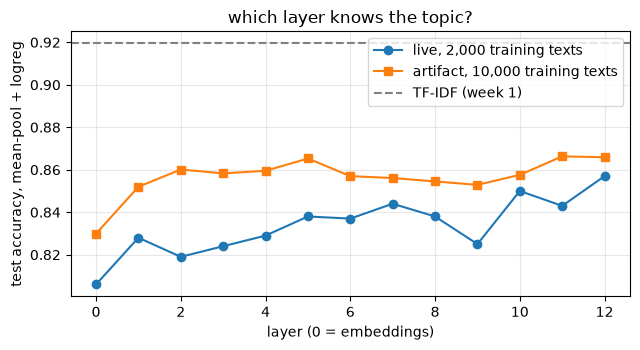

best layer: 11    last layer: 0.8659    best: 0.8663


In [51]:
live_by_layer = [logreg_accuracy(f_train["by_layer"][l].numpy(), y_train, f_test["by_layer"][l].numpy(), y_test)
                 for l in range(f_train["by_layer"].shape[0])]

plt.figure(figsize=(6.5, 3.6))
plt.plot(range(len(live_by_layer)), live_by_layer, "o-", label=f"live, {len(live_train):,} training texts")
plt.plot(range(len(probe["by_layer"])), probe["by_layer"], "s-", label=f"artifact, {probe['n_train']:,} training texts")
plt.axhline(tfidf.accuracy, ls="--", color="gray", label="TF-IDF (week 1)")
plt.xlabel("layer (0 = embeddings)"); plt.ylabel("test accuracy, mean-pool + logreg"); plt.legend(); plt.grid(alpha=.3)
plt.title("which layer knows the topic?"); plt.tight_layout(); plt.show()
print("best layer:", int(np.argmax(probe["by_layer"])), "   last layer:", probe["by_layer"][-1], "   best:", max(probe["by_layer"]))

<!-- Revised 2026-09-23 against artifacts/features_probe.json, by layer: 0.830 0.852 0.860 0.858 0.860 0.865 0.857 0.856 0.855 0.853 0.858 0.866 0.866. -->

Layer 0 is the embedding table — a bag of WordPiece vectors, averaged: 0.83, week 1's "average the word vectors" row. One block of mixing buys two points, the second one more — and then the curve is flat. Layers 2 to 12 all sit between 0.853 and 0.866, inside the noise of a 7 600-text test set. No peak in the middle, no dip at the end.

So, looking at this, you might say that the last layer is more of the *convention*, not a measured choice, and when you freeze a body you probe rather than assume — for AG News, every layer above the second is the same layer.



## 4.2 Head only, top blocks, everything

Now let the body move — a little, then more. `set_trainable(body, k)` unfreezes the top $k$ blocks and leaves the rest as it came. Four settings, same data, same epochs, from the artifacts:

In [52]:
if RECOMPUTE:
    !python precompute.py --only agnews_ft

tr = json.load(open(f"{ART_DIR}/agnews_transfer.json"))
rows = []
for name, run in tr["runs"].items():
    rows.append({"model": name, "top blocks": run["top_blocks"], "lr": run["lr"], "trainable": run["trainable_params"],
                 "share": f"{run['trainable_params'] / run['total_params']:.1%}", "test acc": run["accuracy"][-1], "s/epoch": round(run["seconds"][-1] / run["epoch"][-1])})
    record(f"fine-tune: {name}", run["trainable_params"], run["accuracy"][-1], run["seconds"][-1],
           note=f"{tr['n_train']:,} texts, {tr['epochs']} epochs, lr {run['lr']}")
transfer = pd.DataFrame(rows).set_index("model")
transfer

,top blocks,lr,trainable,share,test acc,s/epoch
model,,,,,,
head only,0,0.00100,3076,0.0%,0.8532,73
top 2 blocks,2,0.00005,14178820,13.0%,0.9043,92
top 6 blocks,6,0.00003,42530308,39.1%,0.9093,126
everything,all,0.00002,108894724,100.0%,0.9108,232


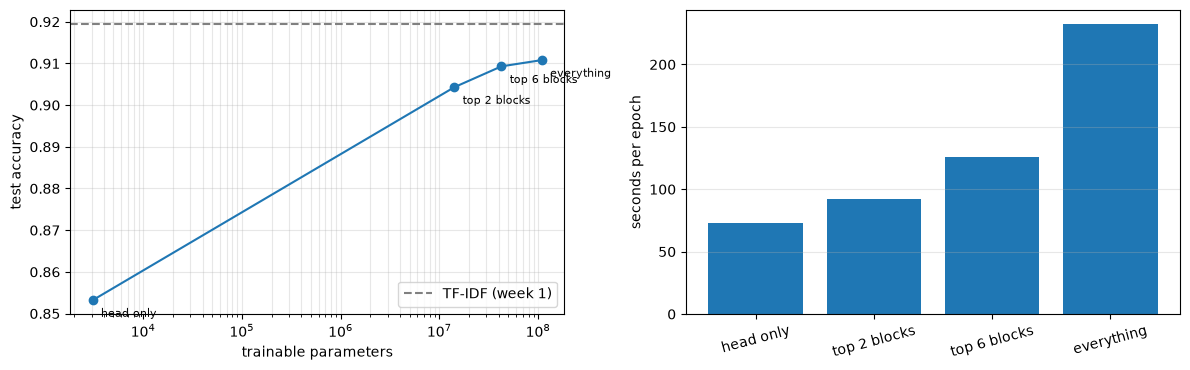

In [53]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.semilogx(transfer["trainable"], transfer["test acc"], "o-")
for name, r in transfer.iterrows():
    a1.annotate(name, (r["trainable"], r["test acc"]), textcoords="offset points", xytext=(6, -12), fontsize=8)
a1.axhline(tfidf.accuracy, ls="--", color="gray", label="TF-IDF (week 1)")
a1.set_xlabel("trainable parameters"); a1.set_ylabel("test accuracy"); a1.legend(); a1.grid(alpha=.3, which="both")
a2.bar(transfer.index, transfer["s/epoch"]); a2.set_ylabel("seconds per epoch"); a2.tick_params(axis="x", labelrotation=15)
a2.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

By looking at it we can see:

* **Head only** is the 2.4 row again, and still under TF-IDF. The x-axis is logarithmic: the next point is *twenty thousand times* more parameters.
* **Two blocks** — 13% of the body — and we almost pass week 1's line. Most of what the classifier needs is a small adjustment to the top of the stack.
* **Six blocks, everything:** a little more each, at the usual diminishing rate. The gap between "top 6" and "everything" is small on this dataset and *will not be* on other tasks than classification, for example, where the relation the task needs has to be built lower down.

Read the right plot as the bill. The forward pass through 110M parameters is paid whatever you freeze; what freezing saves is the *backward* pass and the optimizer state — which, on a real GPU and a real model, is the difference between fitting in memory and not.


# 5. Two more heads: NER and QA

The dial was measured on one task, with the head that reads one vector. Now the two tasks where the head reads all of $H$ — and for each, the two ends of the dial: head only, and everything.



## 5.1 Token classification: NER

**CoNLL-2003** (Tjong Kim Sang & De Meulder 2003): 14 000 Reuters sentences from 1996, every word tagged as a person, an organisation, a location, miscellaneous, or nothing. The task is *named entity recognition*: one label per word. It's on the hub, with one wrinkle worth knowing about — the original repository is a loading *script*, and `datasets` stopped running scripts in v4 (arbitrary code from the hub, executed on your machine, was never a great idea). The hub converts every such dataset to parquet on a branch, and that's the branch we load:

In [55]:
ds = load_dataset("eriktks/conll2003", revision="refs/convert/parquet")   # the repo is a loading script; the hub's parquet conversion lives on this branch
ner_train, ner_val, ner_test = ds["train"], ds["validation"], ds["test"]
check("the hub's tag names are NER_TAGS, in this order", ner_train.features["ner_tags"].feature.names == NER_TAGS)
print(ner_train)
print(ner_train[0]["tokens"])
print([NER_TAGS[t] for t in ner_train[0]["ner_tags"]])

✓ the hub's tag names are NER_TAGS, in this order
Dataset({
    features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
    num_rows: 14041
})
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


Look at the CoNLL labels. `B-ORG` / `I-MISC` / `O` — this is **BIO tagging** (Ramshaw & Marcus 1995): `B-` begins an entity, `I-` continues it, `O` is outside. *Werner Zwingmann* is `B-PER I-PER`, and if two persons stand next to each other, the second one gets a `B-` — which is the only reason the `B` exists at all. The tag set is $2 \times 4 + 1 = 9$ labels.

One label per word. Two problems before the head sees anything, and both are about the tokenizer:

1. The dataset is labelled per word; BERT sees WordPieces. `Zwingmann` is one word with one tag and four tokens.
2. `[CLS]`, `[SEP]` and padding have no tag at all.

`word_ids()` from the fast tokenizer says which word every token came from, and that's enough to fix both:

In [56]:
def encode_ner(tokenizer, ds, max_len=160, label_continuations=False):
    """Words -> WordPiece tokens, and word tags -> token labels. A word can become several tokens
    (`Blackburn` -> `black`, `##burn`); `word_ids()` says which word each token came from.
    The first token of a word gets the word's tag; the continuations get IGNORE — or, with
    `label_continuations=True`, the tag as well (the notebook measures what that does)."""
    def align(batch):
        enc = tokenizer(batch["tokens"], is_split_into_words=True, truncation=True, max_length=max_len)
        enc["labels"], enc["word_ids"] = [], []
        for i, tags in enumerate(batch["ner_tags"]):
            labels, previous = [], None
            for word_id in enc.word_ids(i):
                if word_id is None:                                   # [CLS], [SEP]
                    labels.append(IGNORE)
                elif word_id != previous:                             # first token of a word
                    labels.append(tags[word_id])
                else:                                                 # a continuation
                    labels.append(tags[word_id] if label_continuations else IGNORE)
                previous = word_id
            enc["labels"].append(labels)
            enc["word_ids"].append(enc.word_ids(i))
        return enc
    return ds.map(align, batched=True, remove_columns=ds.column_names)


seqeval = evaluate.load("seqeval")


def ner_metrics(p):
    """Entity-level F1 — an entity counts only if its type AND both boundaries match — next to plain
    token accuracy, which is what "99% correct" usually hides. Positions labelled IGNORE are dropped,
    so both are per *word* (first token), and seqeval reads the BIO tags the way the shared task did."""
    pred, gold = p.predictions.argmax(-1), p.label_ids
    tags_pred = [[NER_TAGS[q] for q, g in zip(pr, gr) if g != IGNORE] for pr, gr in zip(pred, gold)]
    tags_gold = [[NER_TAGS[g] for g in gr if g != IGNORE] for gr in gold]
    r = seqeval.compute(predictions=tags_pred, references=tags_gold)
    return {"entity_f1": round(r["overall_f1"], 4), "token_acc": round(r["overall_accuracy"], 4),
            **{f"f1_{t}": round(r[t]["f1"], 4) for t in ["PER", "ORG", "LOC", "MISC"] if t in r}}


def ner_predictions(logits, features):
    """[N, L, C] logits -> one tag per *word* (read off the word's first token)."""
    out = []
    for row, word_ids in zip(logits.argmax(-1), features["word_ids"]):
        tags, previous = [], None
        for j, word_id in enumerate(word_ids):
            if word_id is not None and word_id != previous:
                tags.append(NER_TAGS[row[j]])
            previous = word_id
        out.append(tags)
    return out

In [49]:
words, tags = ner_train[4]["tokens"], ner_train[4]["ner_tags"]
enc = tokenizer(words, is_split_into_words=True)
print("words   ", words)
print("tokens  ", enc.tokens())
print("word_ids", enc.word_ids())
print()
f = encode_ner(tokenizer, ner_train.select([4]))[0]
for tok, lab in zip(enc.tokens(), f["labels"]):
    print(f"  {tok:12s} {lab:4d}  {NER_TAGS[lab] if lab != IGNORE else '(ignored)'}")

words    ['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']
tokens   ['[CLS]', 'germany', "'", 's', 'representative', 'to', 'the', 'european', 'union', "'", 's', 'veterinary', 'committee', 'werner', 'z', '##wing', '##mann', 'said', 'on', 'wednesday', 'consumers', 'should', 'buy', 'sheep', '##me', '##at', 'from', 'countries', 'other', 'than', 'britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.', '[SEP]']
word_ids [None, 0, 1, 1, 2, 3, 4, 5, 6, 7, 7, 8, 9, 10, 11, 11, 11, 12, 13, 14, 15, 16, 17, 18, 18, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, None]

  [CLS]        -100  (ignored)
  germany         5  B-LOC
  '               0  O
  s            -100  (ignored)
  representative    0  O
  to              0 

`None` for the specials, and the same word id repeated for `zw ##ing ##mann`. The first token of a word carries the tag; the continuations get `-100`, and the cross-entropy inside `BertForTokenClassification` skips them (`ignore_index=-100` is PyTorch's default, which is why the whole ecosystem uses that number). `DataCollatorForTokenClassification` pads the labels with `-100` too. That's it — the head never has to know what a word is.

There's a second option, `label_continuations=True`: give every piece of the word the word's tag. Some tutorials do it, it looks harmless, and it isn't — `B-PER B-PER B-PER B-PER` is four persons in a row to anything that reads BIO. We measure the difference below.

**Bet:** the head-only model on `N_LIVE` sentences, one epoch. Token accuracy — the fraction of words with the right tag — will be above 90%. What's the entity-level F1, where an entity counts only if its type *and both boundaries* are right?

In [44]:
seed_all()
ner_model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=len(NER_TAGS), attn_implementation=ATTN)
set_trainable(ner_model, top_blocks=0)
ner_collator = DataCollatorForTokenClassification(tokenizer)    # pads input_ids with [PAD] and labels with -100

live_ner_tr = encode_ner(tokenizer, ner_train.select(range(N_LIVE)))
live_ner_te = encode_ner(tokenizer, ner_test.select(range(N_LIVE_TEST)))
ner_trainer, ner_live = train(ner_model, live_ner_tr, live_ner_te, ner_collator, ner_metrics, epochs=1, lr=1e-3, batch_size=32)
print({k: v[-1] for k, v in ner_live.items() if isinstance(v, list) and v})

Map: 100%|██████████| 1000/1000 [00:00<00:00, 34080.91 examples/s]


Epoch,Training Loss,Validation Loss,Entity F1,Token Acc,F1 Per,F1 Org,F1 Loc,F1 Misc
1,0.922277,0.641577,0.231600,0.813000,0.109600,0.068500,0.533200,0.000000


{'epoch': 1, 'train_loss': 0.9223, 'seconds': 7.1, 'eval_loss': 0.6415766477584839, 'entity_f1': 0.2316, 'token_acc': 0.813, 'f1_PER': 0.1096, 'f1_ORG': 0.0685, 'f1_LOC': 0.5332, 'f1_MISC': 0.0}


<!-- CHECK LIVE: token accuracy ~0.93–0.95, entity F1 ~0.6–0.7. -->

That gap is the reason the field reports entity F1 and not token accuracy. Most words are `O`; a model that says `O` everywhere gets 83% token accuracy on CoNLL and finds nothing. And an entity with one wrong boundary — `B-PER I-PER` predicted as `B-PER O` — is one wrong token, one *whole* wrong entity. Token accuracy is a metric for the head; entity F1 is a metric for the task.

The full runs are in the artifacts — head only on more sentences, the same with continuations labelled, and the body fully fine-tuned:

In [50]:
if RECOMPUTE:
    !python precompute.py --only ner

ner_art = json.load(open(f"{ART_DIR}/ner_curves.json"))
print(f"{ner_art['n_train']:,} training sentences, {ner_art['n_test']:,} test sentences")
rows = []
for name, run in ner_art["runs"].items():
    rows.append({"model": name, "trainable": run["trainable_params"], "epochs": run["epoch"][-1], "token acc": run["token_acc"][-1],
                 "entity F1": run["entity_f1"][-1], **{f"F1 {t}": run[f"f1_{t}"][-1] for t in ["PER", "ORG", "LOC", "MISC"]}, "s": round(run["seconds"][-1])})
pd.DataFrame(rows).set_index("model")

8,000 training sentences, 3,453 test sentences


,trainable,epochs,token acc,entity F1,F1 PER,F1 ORG,F1 LOC,F1 MISC,s
model,,,,,,,,,
head only,6921,2,0.9535,0.7492,0.8797,0.6403,0.7814,0.6277,66
"head only, continuations labelled",6921,2,0.9486,0.7067,0.8754,0.5539,0.7416,0.6027,62
everything,108898569,3,0.9772,0.8907,0.9631,0.8557,0.9090,0.7702,412


<!-- REVISE AFTER PRECOMPUTE: head-only ~0.75–0.8 F1, continuations a few points lower, full fine-tuning ~0.90. Check MISC is the worst type. -->

Read it as three stories:

* **Head only gets you most of the way.** The frozen body already separates names from non-names — the Linear only has to read it. This is not true of every task; wait for 5.2.
* **Labelling the continuations costs F1** with the same head, the same body, the same data. The extra labels aren't extra information — they're the same tag repeated, and they push the model towards `B-` on continuations, which then reads as a new entity.
* **Fine-tuning the body is worth ten points**, and the points come from `ORG` and `MISC` — the types that depend on context (*Reuters* the company vs *Reuters* the byline; *German* as `MISC` in *German call* but not in a person's name). `PER` and `LOC` were nearly solved by the frozen body.

The fine-tuned model is 220MB and doesn't fit in the repo, so here's what it says on a few sentences it has never seen — including one about a company that opened a store in a city where it hasn't, so nothing can be memorised:

In [57]:
demo = json.load(open(f"{ART_DIR}/ner_predictions.json"))
for s in demo["sentences"][:4]:
    print(" ".join(f"{w}[{t[2:]}]" if t != "O" else w for w, t in zip(s["words"], s["pred"])))
    print()

Germany[LOC] 's representative to the European[ORG] Union[ORG] 's veterinary committee Werner[PER] Zwingmann[PER] said on Wednesday consumers should buy sheepmeat from countries other than Britain[LOC] .

Apple[ORG] opened its first store in Moscow[LOC] on Tuesday , chief executive Tim[PER] Cook[PER] told Reuters[ORG] .

The Hague[LOC] court ruled against Shell[ORG] in a case brought by Friends[ORG] of[ORG] the[ORG] Earth[ORG] Netherlands[ORG] .

SOCCER - JAPAN[LOC] GET LUCKY WIN , CHINA[LOC] IN SURPRISE DEFEAT .



## 5.2 Two pointers: extractive QA

The other task that reads all of $H$, with the other softmax axis. **SQuAD v1.1** (Rajpurkar et al. 2016): 100 000 questions about Wikipedia paragraphs, where the answer is always a *span of the paragraph* — the task is *extractive question answering*, two positions per question. From the hub again, with no wrinkle this time:

In [58]:
ds = load_dataset("rajpurkar/squad")
qa_train, qa_dev = ds["train"].shuffle(seed=SEED), ds["validation"]       # train is ordered by article; a live subset should not be one article
print(qa_train)
e = qa_dev[0]
print("Q:", e["question"]); print("A:", e["answers"]); print("context:", e["context"][:200], "...")

Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 87599
})
Q: Which NFL team represented the AFC at Super Bowl 50?
A: {'text': ['Denver Broncos', 'Denver Broncos', 'Denver Broncos'], 'answer_start': [177, 177, 177]}
context: Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated ...


The answer is a *character offset* into the paragraph, not a token — and the dev set carries several human answers per question, which is what the official metric averages over. The data has a catch, and it's this offset:

In [59]:
e = next(x for x in qa_train.select(range(500)) if 500 < len(x["context"]) < 700)     # long enough to need two windows below
text, start = e["answers"]["text"][0], e["answers"]["answer_start"][0]
print("Q:      ", e["question"])
print("answer: ", repr(text), " at character", start)
print("context:", e["context"][:start], "[[", e["context"][start:start + len(text)], "]]", e["context"][start + len(text):][:80], "...")

Q:       What percentage of Egyptians polled support death penalty for those leaving Islam?
answer:  '84%'  at character 468
context: The Pew Forum on Religion & Public Life ranks Egypt as the fifth worst country in the world for religious freedom. The United States Commission on International Religious Freedom, a bipartisan independent agency of the US government, has placed Egypt on its watch list of countries that require close monitoring due to the nature and extent of violations of religious freedom engaged in or tolerated by the government. According to a 2010 Pew Global Attitudes survey,  [[ 84% ]]  of Egyptians polled supported the death penalty for those who leave Islam; 77%  ...


The label is a *character* offset into the paragraph — one number. Where's the end? `start + len(text)`. And where's the *token*? Nowhere yet: the paragraph will be tokenized, and we need the answer as a `(start token, end token)` pair. Two more things go wrong on the way:

* **The question and the paragraph are two segments.** `[CLS] question [SEP] context [SEP]`, with `token_type_ids` 0 and 1 — the segment embedding, at last doing its job.
* **Paragraphs are long.** BERT stops at 512 tokens, and we'd rather use 384 for speed. Cutting the question is not an option; cutting the paragraph loses the answer half the time. So the paragraph is cut into *overlapping windows* — `stride` tokens of overlap — and each window becomes one training example, with the label pointing at the answer if it's inside and at `[CLS]` (position 0) if it isn't.

The tokenizer does all of the mechanics, if you ask for them:

In [60]:
enc = tokenizer(e["question"], e["context"], truncation="only_second", max_length=128, stride=32,
                return_overflowing_tokens=True, return_offsets_mapping=True)
print(f"{len(enc['input_ids'])} windows from one question, all from example {set(enc['overflow_to_sample_mapping'])}")
print("segment ids of window 0:", enc.sequence_ids(0)[:4], "...", enc.sequence_ids(0)[-4:], "   None = special, 0 = question, 1 = context")
print("offsets of window 0:    ", list(zip(enc.tokens(0), enc["offset_mapping"][0]))[:10])

2 windows from one question, all from example {0}
segment ids of window 0: [None, 0, 0, 0] ... [1, 1, 1, None]    None = special, 0 = question, 1 = context
offsets of window 0:     [('[CLS]', (0, 0)), ('what', (0, 4)), ('percentage', (5, 15)), ('of', (16, 18)), ('egyptians', (19, 28)), ('polled', (29, 35)), ('support', (36, 43)), ('death', (44, 49)), ('penalty', (50, 57)), ('for', (58, 61))]


`offset_mapping` is the bridge: for every token, the character span it came from. Walk the context tokens, find the first one that ends after `answer_start` and the last one that starts before `answer_end`, and that's the label. `encode_qa` below does exactly this, and it's the longest function of the day — not because the idea is hard, but because three coordinate systems (characters, tokens, windows) have to agree.

In [61]:
def encode_qa(tokenizer, ds, max_len=384, stride=128):
    """question + context -> [CLS] question [SEP] context [SEP], with the context cut into
    overlapping windows when it does not fit. Each window becomes one row; the label is the
    (start, end) *token* position of the answer inside that window, or (0, 0) — the [CLS]
    position — when the answer is not in this window. `offset_mapping` (kept for the context
    tokens only) is what turns a predicted token span back into text."""
    def windows(batch):
        enc = tokenizer([q.strip() for q in batch["question"]], batch["context"], truncation="only_second",
                        max_length=max_len, stride=stride, return_overflowing_tokens=True, return_offsets_mapping=True)
        sample = enc.pop("overflow_to_sample_mapping")
        enc["example_id"], enc["start_positions"], enc["end_positions"] = [], [], []
        for i, offsets in enumerate(enc["offset_mapping"]):
            j = sample[i]
            seq_ids = enc.sequence_ids(i)                              # None = special, 0 = question, 1 = context
            context_tokens = [k for k, s in enumerate(seq_ids) if s == 1]
            first, last = context_tokens[0], context_tokens[-1]
            answers = batch["answers"][j]
            start = end = 0
            if answers["text"]:
                answer_start = answers["answer_start"][0]
                answer_end = answer_start + len(answers["text"][0])
                if offsets[first][0] <= answer_start and offsets[last][1] >= answer_end:   # the answer is inside this window
                    start = next(k for k in context_tokens if offsets[k][1] > answer_start)
                    end = next(k for k in reversed(context_tokens) if offsets[k][0] < answer_end)
            enc["example_id"].append(batch["id"][j])
            enc["start_positions"].append(start)
            enc["end_positions"].append(end)
            enc["offset_mapping"][i] = [o if s == 1 else None for o, s in zip(offsets, seq_ids)]
        return enc
    return ds.map(windows, batched=True, remove_columns=ds.column_names)


def best_span(start_scores, end_scores, offsets, max_answer_tokens=30):
    """The highest-scoring (start, end) pair with start <= end, both inside the context, and the
    answer no longer than `max_answer_tokens`. Returns the score and the character span."""
    best, best_span_ = -1e9, None
    starts = np.argsort(start_scores)[::-1][:20]                 # only the 20 best starts and ends are worth checking
    ends = np.argsort(end_scores)[::-1][:20]
    for s in starts:
        for e in ends:
            if offsets[s] is None or offsets[e] is None or e < s or e - s + 1 > max_answer_tokens:
                continue
            if start_scores[s] + end_scores[e] > best:
                best, best_span_ = start_scores[s] + end_scores[e], (offsets[s][0], offsets[e][1])
    return best, best_span_


def qa_answers(start_logits, end_logits, features, examples):
    """Model outputs on every window -> one text answer per example (the best window wins)."""
    best = {}
    for start_scores, end_scores, offsets, example_id in zip(start_logits, end_logits, features["offset_mapping"], features["example_id"]):
        score, span = best_span(start_scores[:len(offsets)], end_scores[:len(offsets)], offsets)
        if span is not None and score > best.get(example_id, (-1e9, None))[0]:
            best[example_id] = (score, span)
    return {i: ("" if i not in best else context[best[i][1][0]:best[i][1][1]]) for i, context in zip(examples["id"], examples["context"])}


squad_metric = evaluate.load("squad")                                # the official SQuAD script: exact match and token F1,
                                                                     # each the max over the human answers, then averaged

def qa_metrics_for(features, examples):
    """`compute_metrics` for the Trainer needs the windows and the examples the logits came from — so it
    is built per eval set. The Trainer hands over (start_logits, end_logits) in the dataset's order."""
    references = [{"id": i, "answers": a} for i, a in zip(examples["id"], examples["answers"])]

    def metrics(p):
        start_logits, end_logits = p.predictions
        answers = qa_answers(start_logits, end_logits, features, examples)
        r = squad_metric.compute(predictions=[{"id": i, "prediction_text": a} for i, a in answers.items()], references=references)
        return {"exact_match": round(r["exact_match"], 2), "f1": round(r["f1"], 2)}
    return metrics

In [62]:
f = encode_qa(tokenizer, Dataset.from_dict({k: [v] for k, v in e.items()}), max_len=128, stride=32)
for w in f:
    s, t = w["start_positions"], w["end_positions"]
    span = "(not in this window)" if (s, t) == (0, 0) else repr(e["context"][w["offset_mapping"][s][0]:w["offset_mapping"][t][1]])
    print(f"window of example {w['example_id']}: {len(w['input_ids'])} tokens, label ({s}, {t}) -> {span}")

Map: 100%|██████████| 1/1 [00:00<00:00, 99.39 examples/s]

window of example 573173d8497a881900248f0c: 128 tokens, label (97, 98) -> '84%'
window of example 573173d8497a881900248f0c: 60 tokens, label (17, 18) -> '84%'


The label decodes back to the answer text in the window that contains it, and to nothing in the others. If that round trip fails on your own data, nothing downstream can work — check it before you train, always.

Now the head. `SpanHead` gives two scores per token; `span_loss` is cross-entropy over the *position* axis, twice — and `AutoModelForQuestionAnswering` is exactly that head (3.3), its loss reading `start_positions` and `end_positions` from the batch. At prediction time we don't take `argmax` twice independently — we take the best pair with `start <= end`, both inside the context, at most 30 tokens apart (`best_span`); otherwise "the end before the start" is a real answer the model can give you. The score is the official SQuAD script, loaded with `evaluate`: exact match and token F1, each the best over the human answers.

**Bet:** the same head-only setup as NER — frozen body, one epoch, `N_LIVE` questions. NER got most of the way on frozen features. Will QA?

In [63]:
seed_all()
qa_model = AutoModelForQuestionAnswering.from_pretrained(MODEL_NAME, attn_implementation=ATTN)
set_trainable(qa_model, top_blocks=0)

live_qa_ex, live_dev_ex = qa_train.select(range(N_LIVE)), qa_dev.select(range(N_LIVE_TEST // 2))
live_qa_tr, live_qa_de = encode_qa(tokenizer, live_qa_ex), encode_qa(tokenizer, live_dev_ex)
print(f"{len(live_qa_ex):,} questions -> {len(live_qa_tr):,} windows")
qa_trainer, qa_live = train(qa_model, live_qa_tr, live_qa_de, collator, qa_metrics_for(live_qa_de, live_dev_ex), epochs=1, lr=1e-3, batch_size=32)
print({k: v[-1] for k, v in qa_live.items() if isinstance(v, list) and v})

Map: 100%|██████████| 500/500 [00:00<00:00, 6684.47 examples/s]


2,000 questions -> 2,015 windows


Epoch,Training Loss,Validation Loss,Exact Match,F1
1,5.060289,4.404224,3.600000,10.760000


{'epoch': 1, 'train_loss': 5.0603, 'seconds': 61.0, 'eval_loss': 4.404223918914795, 'exact_match': 3.6, 'f1': 10.76}


<!-- CHECK LIVE: F1 in the low teens or worse. -->

It will not. And this is the most useful negative result of the day: **the same frozen body that hands NER 75 F1 hands QA almost nothing.** "Is this token a name" is a property of the token that the MLM objective happened to need; "does this token start the answer to *that* question" is a relation between two segments that nothing in pretraining asked for. The vectors don't contain it, and a Linear can only read what's there.

So for QA the body has to move. The artifacts have the fully fine-tuned run:

In [64]:
if RECOMPUTE:
    !python precompute.py --only qa

qa_art = json.load(open(f"{ART_DIR}/qa_curves.json"))
rows = [{"model": name, "trainable": run["trainable_params"], "epochs": run["epoch"][-1],
         "dev EM": run["exact_match"][-1], "dev F1": run["f1"][-1], "s": round(run["seconds"][-1])} for name, run in qa_art["runs"].items()]
print(f"{qa_art['n_train']:,} training questions -> {qa_art['n_train_windows']:,} windows;  dev {qa_art['n_dev']:,} questions")
pd.DataFrame(rows).set_index("model")

5,000 training questions -> 5,048 windows;  dev 2,000 questions


,trainable,epochs,dev EM,dev F1,s
model,,,,,
head only,1538,1,11.15,19.10,112
everything,108893186,2,67.75,76.74,987


<!-- REVISE AFTER PRECOMPUTE: head-only F1 ~10–20, full fine-tuning ~80–85 on 30k questions (the --full tier); the demo tier trains on 5k, expect less. -->

Sixty-plus points of F1 between the two rows, and the only difference is whether the 110M parameters were allowed to move. The head is the same 1 538 numbers in both.

And what it does, on a paragraph it has certainly never seen:

In [65]:
demo = json.load(open(f"{ART_DIR}/qa_predictions.json"))
print(demo["examples"][0]["context"], "\n")
for ex in demo["examples"]:
    if ex["context"] == demo["examples"][0]["context"]:
        print(f"  Q: {ex['question']:42s} A: {ex['pred']!r}")
print()
for ex in demo["examples"][4:8]:
    print(f"  Q: {ex['question']:60s} pred {ex['pred']!r:28s} gold {ex['gold'][0]!r}")

The Higher School of Economics was founded in 1992 in Moscow. Its DSBA programme is taught in English and was launched together with the University of London in 2019. The NLP course runs in the autumn of the fourth year. 

  Q: When was HSE founded?                      A: '1992'
  Q: In what language is DSBA taught?           A: 'English'
  Q: Which university partners with DSBA?       A: 'University of London'
  Q: When does the NLP course run?              A: 'autumn of the fourth year'

  Q: Which NFL team represented the AFC at Super Bowl 50?         pred 'American Football Conference (AFC) champion Denver Broncos' gold 'Denver Broncos'
  Q: Which NFL team represented the NFC at Super Bowl 50?         pred 'Carolina Panthers'          gold 'Carolina Panthers'
  Q: Where did Super Bowl 50 take place?                          pred "Levi's Stadium"             gold 'Santa Clara, California'
  Q: Which NFL team won Super Bowl 50?                            pred 'National Football Leag

❓ **Open question 2:** the model *always* answers. Give it a question whose answer is not in the paragraph and it will still pick the best-scoring span. SQuAD 2.0 (2018) added unanswerable questions, and the standard fix is to let position 0 — `[CLS]` — win the two softmaxes. Why does that work with the head we have, without adding a single parameter?

# 6. Where this goes

Put the results table back up and read it as one story.

In [66]:
show_results()

,trainable params,test acc,train s,note
model,,,,
TF-IDF + logreg (week 1),—,0.9195,20.0,"tf-idf, words 1-2"
"zero-shot MLM, politics/sports/business/technology",0,0.4682,NaN,prompt: This news is about [MASK].
pooler + logreg,0,0.8679,NaN,"body frozen, 10,000 texts"
frozen [CLS] + logreg,0,0.8579,NaN,"body frozen, 10,000 texts"
frozen mean-pool + logreg,0,0.8659,NaN,"body frozen, 10,000 texts"
"head only, live (2,000 texts, 1 epoch)","3,076",0.4910,14.0,"body frozen, pooler included"
"head only, live (2,000 texts, 1 epoch)","3,076",0.5660,17.0,"body frozen, pooler included"
fine-tune: head only,"3,076",0.8532,145.0,"6,000 texts, 2 epochs, lr 0.001"
fine-tune: top 2 blocks,14.2M,0.9043,185.0,"6,000 texts, 2 epochs, lr 5e-05"


<!-- REVISE AFTER PRECOMPUTE: align the story with the numbers. -->

Every row is the same equation — a pretrained body × a head × what you let move — and the rows are ordered by the third factor:

* **nothing moves** (zero-shot): the body knows things, we can reach them through the pretraining interface, and a word in the prompt is worth ten points. Under TF-IDF.
* **a Linear moves** (frozen features, head only): a logistic regression on whichever vector you choose — and the choice matters, the pooler is the worst and the last layer isn't the best. Still under TF-IDF. A frozen body that was never asked about topics does not hand over topic features.
* **the top of the body moves**: two blocks and we pass week 1; six and we're near the ceiling. The task-relevant adjustment lives near the top, because the top is the part pretraining specialised.
* **everything moves**: the best number, the biggest bill, and — at the wrong learning rate or the wrong seed — the only setting that can *destroy* the body.

And across the three tasks, one Linear each: `[B, C]` from one vector, `[B, L, C]` softmaxed over classes, `[B, L, 2]` softmaxed over positions. Where the head attaches and which axis is normalised — that was the task. How much of the body has to move to feed it — that depended on whether pretraining had already built what the task needs (names: yes; the answer to a question: no).

**Five things that transfer to every model this course will touch:**

1. **A tokenizer is a trained model with its own algorithm.** Vocabulary ≠ tokenizer; BPE and WordPiece differ by a score and an encoder; Unigram is a distribution, and you can sample from it.
2. **The pretraining objective decides what the vectors contain.** MLM's 80/10/10 is why unmasked tokens carry context; NSP is why the pooler is useless; the last layer is bent towards the objective and the ones below it aren't.
3. **The head is a Linear; the task is its shape and its softmax axis.** `AutoModelFor*` is those five lines. Read them once.
4. **Transfer is a dial with two axes** — how much you unfreeze and how gently — and the right setting depends on whether pretraining already built the thing the task needs.
5. **Fine-tuning has a variance**, and a single number from a single seed on a small dataset is not a result.

Next week: the *other* half of the transformer, pretrained the same way — and what changes when the body is a decoder and the head is the vocabulary.

## Try it yourself

* **Extractive summarisation as token classification.** Take the SAMSum dialogues (`knkarthick/samsum` on the hub) and build an `AutoModelForTokenClassification` with two labels — "this token is in the summary" / "it isn't" — by marking the dialogue tokens that also appear in the human summary. Train it head-only and fully. Then look at the labels you built: SAMSum summaries are *abstractive* (written, not copied), so what fraction of the summary tokens are actually in the dialogue, and what does that do to the ceiling of your model? Write two sentences about when this task formulation is honest and when it isn't.
* **The probe, for NER.** Repeat 4.1 with a token head (one `Linear`, as in 3.2) instead of a logistic regression: freeze the body, train the head on *each* layer's token vectors separately, one epoch each, and plot entity F1 by layer. Does NER peak at the same depth as topic classification? (Tenney et al. 2019 say no. Check.)
* **Three tokenizers, one model.** Train a WordPiece and a Unigram vocabulary of 8 000 on the jokes from week 2 with the `tokenizers` library (`models.WordPiece` + `trainers.WordPieceTrainer`, `models.Unigram` + `trainers.UnigramTrainer`), and retrain week 2's LSTM language model on each. Report tokens per joke, perplexity — and think about why the perplexities are *not* directly comparable, then make them comparable (week 2, 2.4).
* **Unanswerable questions.** Take 200 dev questions, swap their paragraphs with each other, and run the fine-tuned QA model (retrain it with `precompute.py --only qa` — it isn't in the repo). It will answer every one. Add the `[CLS]`-wins rule from Open question 2 with a threshold on the score difference, and plot precision/recall of "no answer" against the threshold.

## References

**Tokenization.** Schuster & Nakajima (2012), *Japanese and Korean Voice Search* — WordPiece. Wu et al. (2016), *Google's Neural Machine Translation System* — the WordPiece description everyone cites. Sennrich, Haddow & Birch (2016), *Neural Machine Translation of Rare Words with Subword Units* — BPE. Kudo (2018), *Subword Regularization* — the Unigram model. Kudo & Richardson (2018), *SentencePiece*. Bostrom & Durrett (2020), *Byte Pair Encoding is Suboptimal for Language Model Pretraining*.

**Pretraining.** Devlin et al. (2019), *BERT*. Liu et al. (2019), *RoBERTa* — NSP removed. Peters et al. (2018), *Deep Contextualized Word Representations* — ELMo, and the first layer-wise probing. Clark et al. (2020), *ELECTRA*. Lan et al. (2020), *ALBERT*.

**What the layers hold.** Tenney, Das & Pavlick (2019), *BERT Rediscovers the Classical NLP Pipeline*. Liu et al. (2019), *Linguistic Knowledge and Transferability of Contextual Representations*. Reimers & Gurevych (2019), *Sentence-BERT* — why raw `[CLS]` is a poor sentence vector.

**Transfer.** Howard & Ruder (2018), *ULMFiT* — discriminative learning rates and gradual unfreezing. Peters, Ruder & Smith (2019), *To Tune or Not to Tune?* Mosbach, Andriushchenko & Klakow (2021), *On the Stability of Fine-tuning BERT*. Houlsby et al. (2019), *Parameter-Efficient Transfer Learning for NLP* — adapters. Hu et al. (2021), *LoRA*.

**Tasks.** Tjong Kim Sang & De Meulder (2003), *The CoNLL-2003 Shared Task*. Ramshaw & Marcus (1995), *Text Chunking* — BIO. Rajpurkar et al. (2016), *SQuAD*; Rajpurkar, Jia & Liang (2018), *Know What You Don't Know* — SQuAD 2.0. Wang et al. (2019), *GLUE*.